In [1]:
import numpy as np 
import matplotlib.pyplot as plt 

from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN

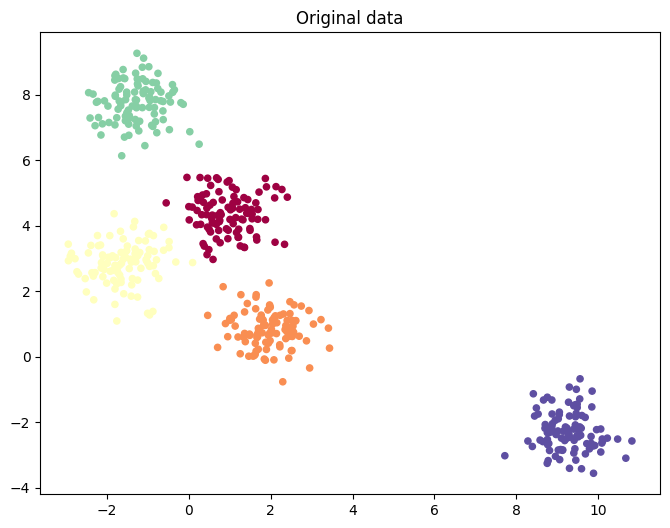

In [2]:
X, y = make_blobs(
    n_samples=500,
    n_features=2,
    centers=5,
    cluster_std=0.6,
    random_state=0
)

colors = np.array([
    plt.cm.Spectral(val)
    for val in np.linspace(0, 1, len(set(y)))
])

plt.figure(figsize=(8,6))
plt.scatter(X[:,0], X[:,1], c=colors[y], s=20)
plt.title("Original data")
plt.show()

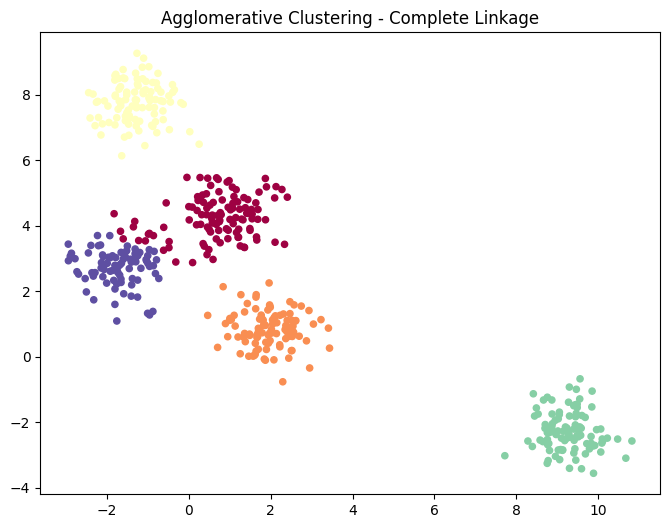

In [3]:
agg_complete = AgglomerativeClustering(
    n_clusters=5,
    linkage='complete'
)

pred_complete = agg_complete.fit_predict(X)

plt.figure(figsize=(8,6))
plt.scatter(X[:,0], X[:,1], c=colors[pred_complete], s=20)
plt.title("Agglomerative Clustering - Complete Linkage")
plt.show()

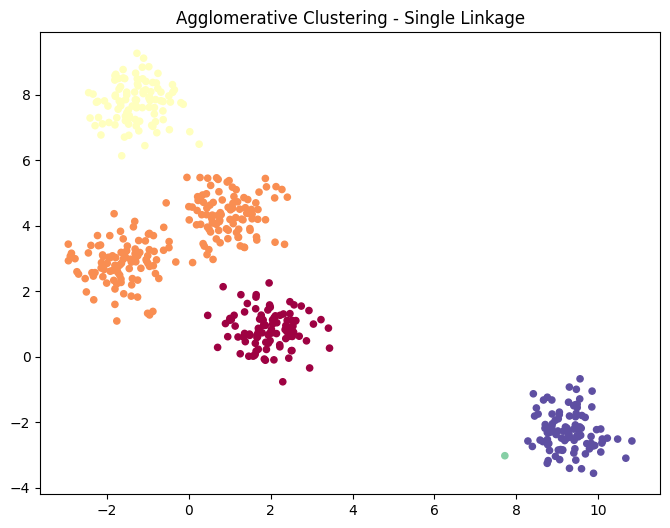

In [4]:
agg_single = AgglomerativeClustering(
    n_clusters=5,
    linkage='single'
)

pred_single = agg_single.fit_predict(X)

plt.figure(figsize=(8,6))
plt.scatter(X[:,0], X[:,1], c=colors[pred_single], s=20)
plt.title("Agglomerative Clustering - Single Linkage")
plt.show()

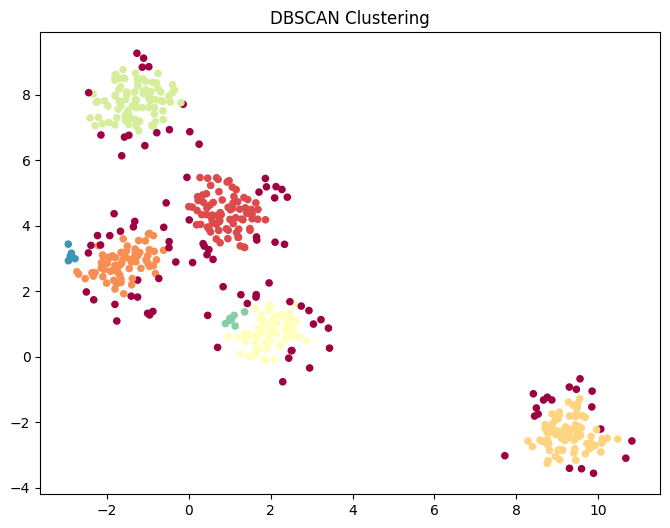

In [5]:
dbscan = DBSCAN(eps=0.3, min_samples=5)
pred_db = dbscan.fit_predict(X)

# обробка noise (-1)
unique_labels = np.unique(pred_db)
db_colors = np.array([
    plt.cm.Spectral(i / len(unique_labels))
    for i in range(len(unique_labels))
])

label_to_color = {label: db_colors[i] for i, label in enumerate(unique_labels)}

plt.figure(figsize=(8,6))
plt.scatter(
    X[:,0],
    X[:,1],
    c=[label_to_color[l] for l in pred_db],
    s=20
)
plt.title("DBSCAN Clustering")
plt.show()

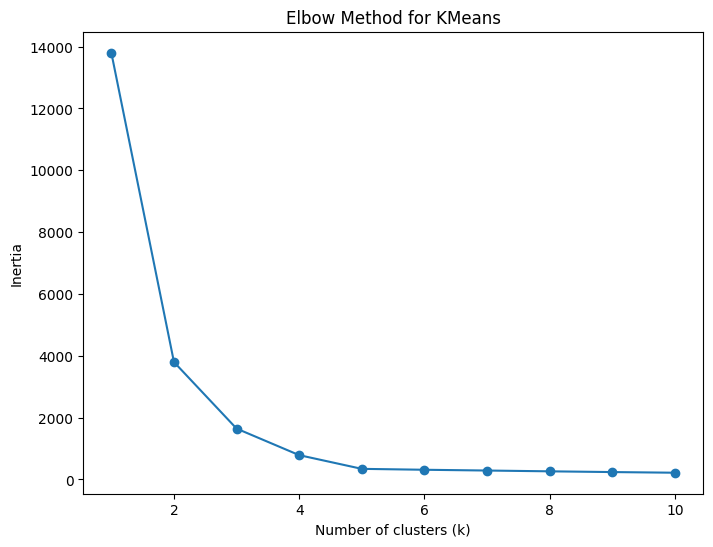

In [6]:
inertias = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=0, n_init=10)
    kmeans.fit(X)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(8,6))
plt.plot(K_range, inertias, marker='o')
plt.title("Elbow Method for KMeans")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.show()